## linux graph library install
- sudo apt update  
- sudo apt install -y libgl1  


image 1/1 /workspace/객체탐지/sample.png: 352x640 1 backpack, 1 handbag, 1 bottle, 1 cup, 1 chair, 2 potted plants, 1 laptop, 1 mouse, 1 keyboard, 4 books, 23.8ms
Speed: 1.9ms preprocess, 23.8ms inference, 18.3ms postprocess per image at shape (1, 3, 352, 640)
Objects detected: 14


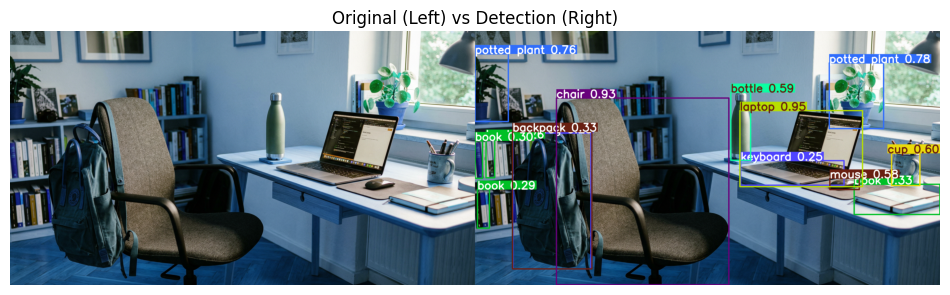

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 모델 불러오기
model = YOLO("yolov8n.pt")

# 추론 실행
results = model("sample.png", conf=0.25, iou=0.45)

# 결과
result = results[0]
print(f"Objects detected: {len(result.boxes)}")

# 이미지 가져오기
original = result.orig_img
annotated = result.plot()

# 좌/우 붙이기 (가로 concat)
combined = np.hstack((original, annotated))

# 크기 줄이기 (예: 50%)
scale = 0.5
combined_resized = cv2.resize(
    combined,
    (int(combined.shape[1]*scale), int(combined.shape[0]*scale))
)

# Matplotlib으로 출력
plt.figure(figsize=(12, 6))
plt.imshow(combined_resized)
plt.axis("off")
plt.title("Original (Left) vs Detection (Right)")
plt.show()

# OpenCV로 출력 -window에서
# cv2.namedWindow("Result", cv2.WINDOW_NORMAL)
# cv2.imshow("Result", combined_resized)

# cv2.waitKey(0)
# cv2.destroyAllWindows()